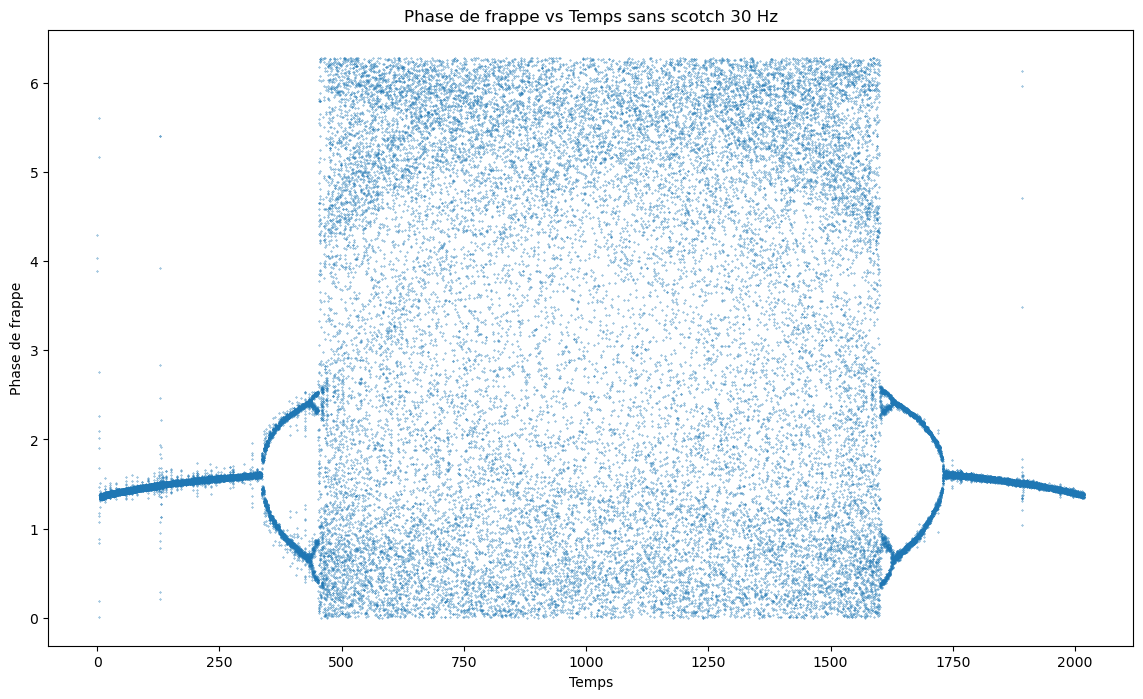

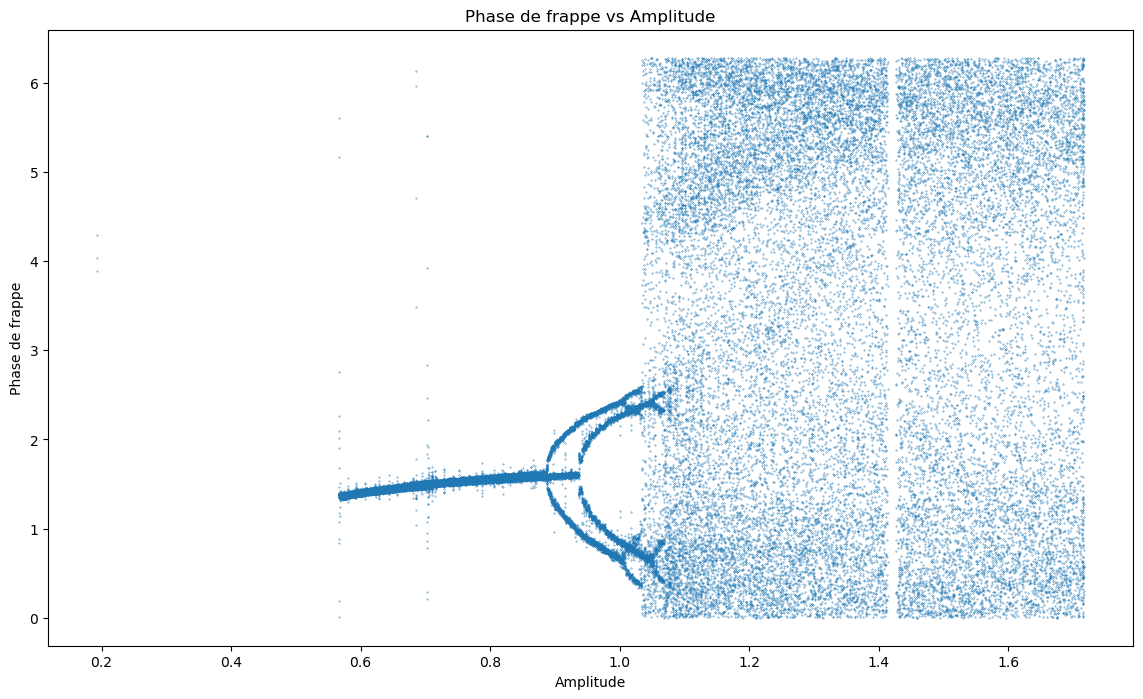

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

file_path = "Sans scotch 30Hz.xlsx"

df = pd.read_excel(file_path)

temps = df.iloc[:, 0]
phase = df.iloc[:, 4]

plt.figure(figsize=(14, 8))  # ← largeur, hauteur en pouces

plt.plot(temps, phase,
         linestyle='None',
         marker='.',
         markersize=0.6)

plt.xlabel("Temps")
plt.ylabel("Phase de frappe")
plt.title("Phase de frappe vs Temps sans scotch 30 Hz")

plt.show()

temps = df.iloc[:, 2]
phase = df.iloc[:, 4]

plt.figure(figsize=(14, 8))  # ← largeur, hauteur en pouces

plt.plot(temps, phase,
         linestyle='None',
         marker='.',
         markersize=0.6)

plt.xlabel("Amplitude")
plt.ylabel("Phase de frappe")
plt.title("Phase de frappe vs Amplitude")

plt.show()

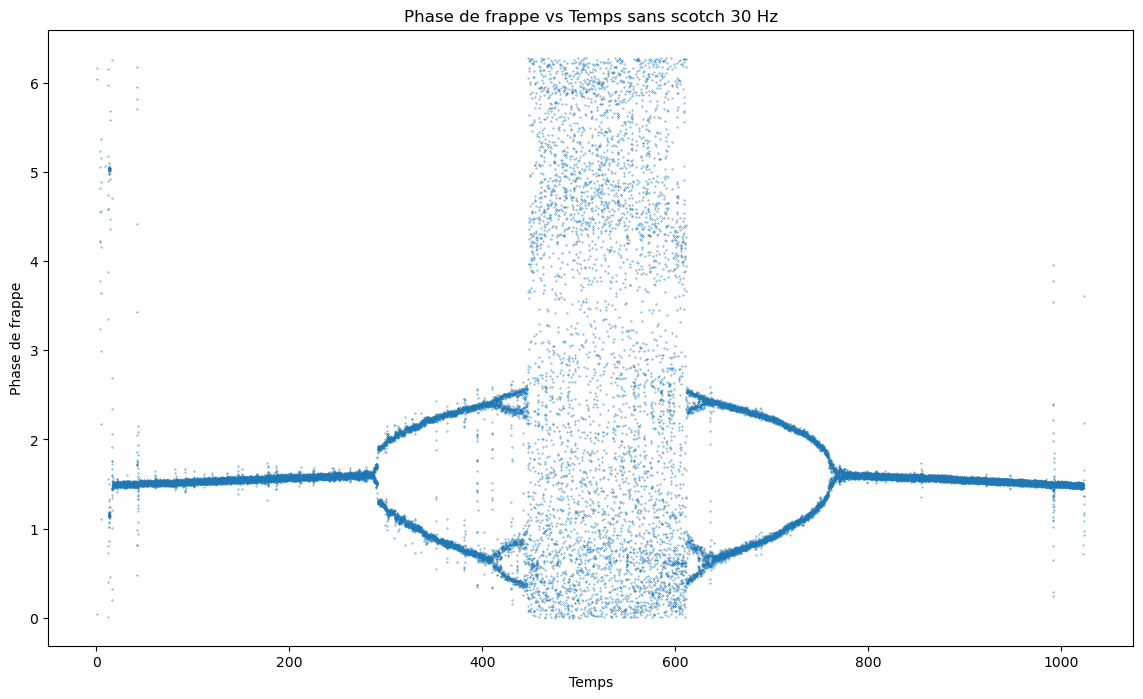

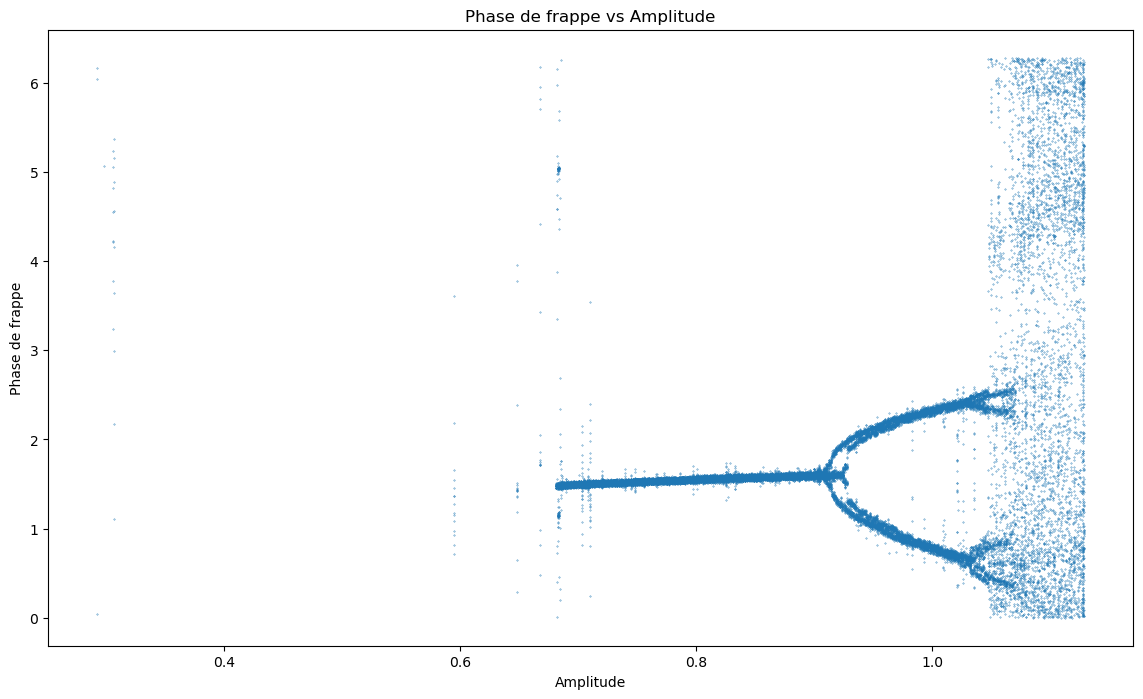

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

file_path = "Sans scotch 30Hz.xlsx"

df = pd.read_excel(file_path, sheet_name = 1)

temps = df.iloc[:, 0]
phase = df.iloc[:, 4]

plt.figure(figsize=(14, 8))  # ← largeur, hauteur en pouces

plt.plot(temps, phase,
         linestyle='None',
         marker='.',
         markersize=0.6)

plt.xlabel("Temps")
plt.ylabel("Phase de frappe")
plt.title("Phase de frappe vs Temps sans scotch 30 Hz (Zoom)")

plt.show()

temps = df.iloc[:, 2]
phase = df.iloc[:, 4]

plt.figure(figsize=(14, 8))  # ← largeur, hauteur en pouces

plt.plot(temps, phase,
         linestyle='None',
         marker='.',
         markersize=0.6)

plt.xlabel("Amplitude")
plt.ylabel("Phase de frappe")
plt.title("Phase de frappe vs Amplitude (Zoom)")

plt.show()

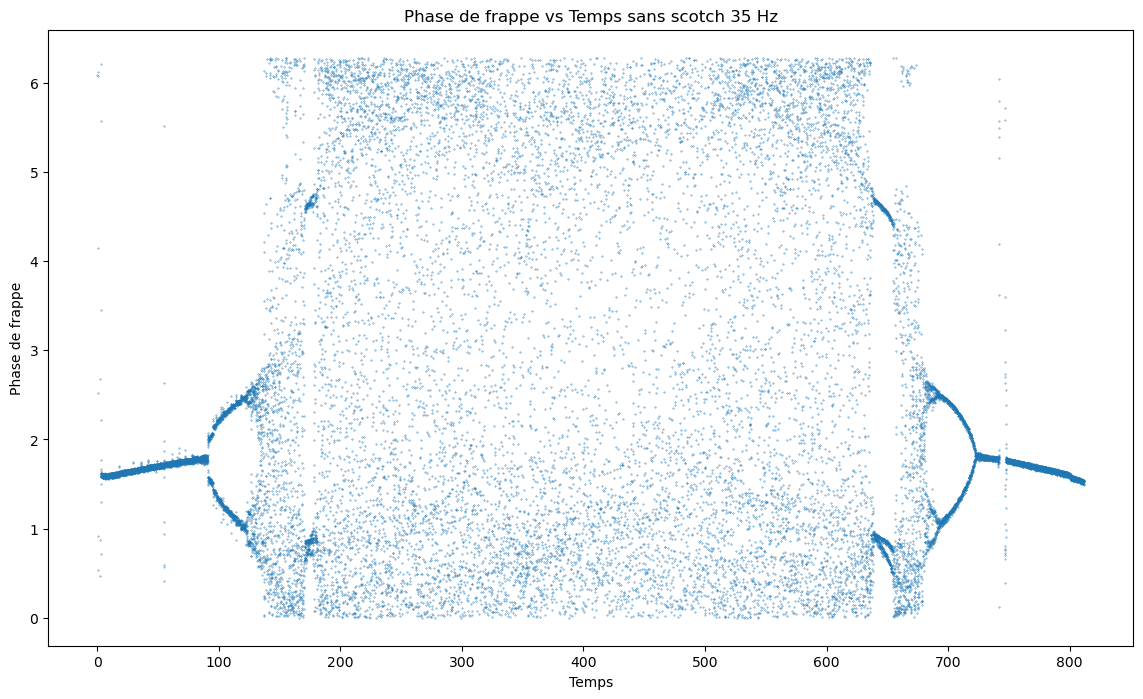

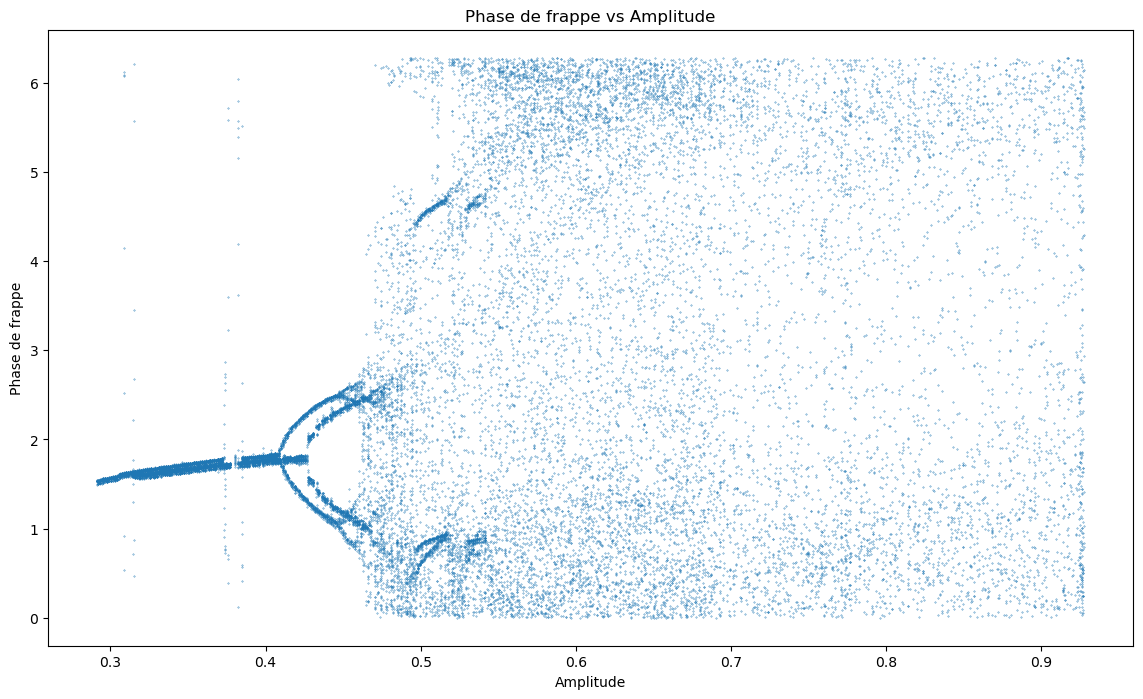

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

file_path = "Sans scotch 30Hz.xlsx"

df = pd.read_excel(file_path, sheet_name = 2)

temps = df.iloc[:, 0]
phase = df.iloc[:, 4]

plt.figure(figsize=(14, 8))  # ← largeur, hauteur en pouces

plt.plot(temps, phase,
         linestyle='None',
         marker='.',
         markersize=0.6)

plt.xlabel("Temps")
plt.ylabel("Phase de frappe")
plt.title("Phase de frappe vs Temps sans scotch 35 Hz")

plt.show()

temps = df.iloc[:, 2]
phase = df.iloc[:, 4]

plt.figure(figsize=(14, 8))  # ← largeur, hauteur en pouces

plt.plot(temps, phase,
         linestyle='None',
         marker='.',
         markersize=0.6)

plt.xlabel("Amplitude")
plt.ylabel("Phase de frappe")
plt.title("Phase de frappe vs Amplitude 35 Hz")

plt.show()

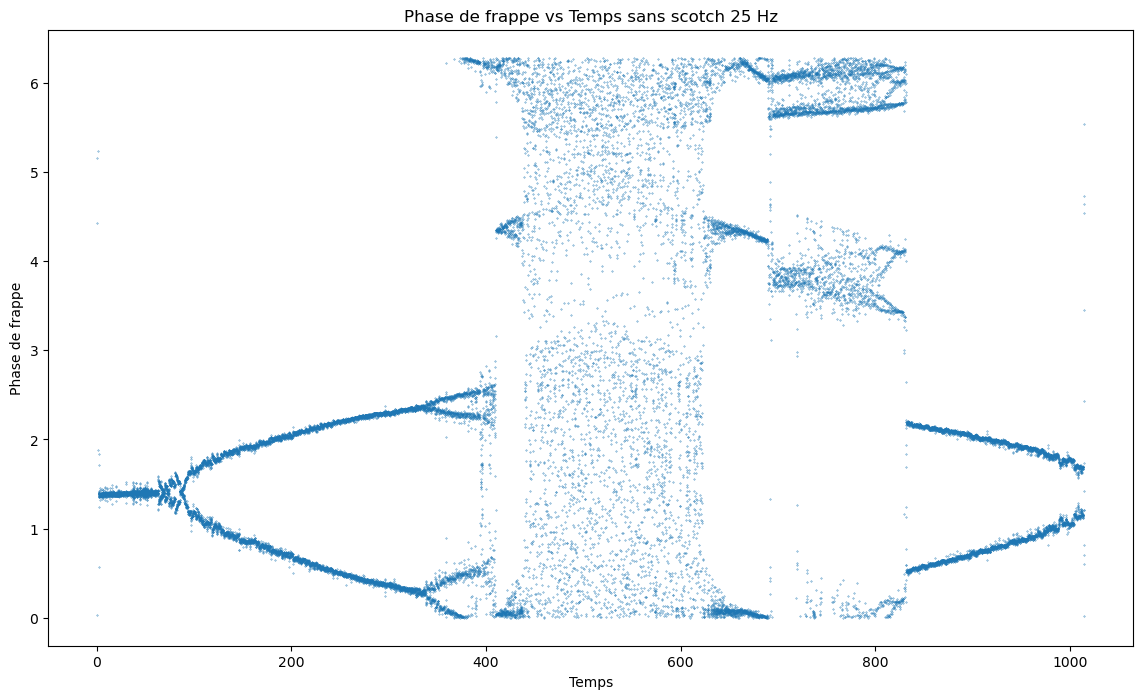

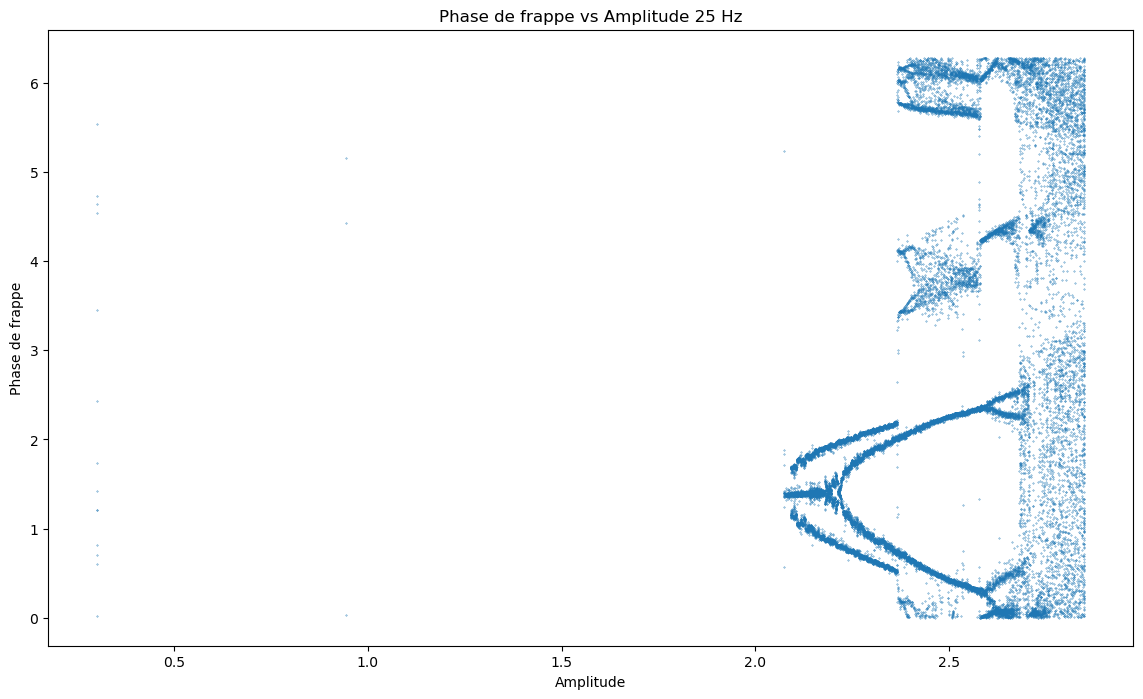

In [35]:
import pandas as pd
import matplotlib.pyplot as plt

file_path = "Sans scotch 30Hz.xlsx"

df = pd.read_excel(file_path, sheet_name = 3)

temps = df.iloc[:, 0]
phase = df.iloc[:, 4]

plt.figure(figsize=(14, 8))  # ← largeur, hauteur en pouces

plt.plot(temps, phase,
         linestyle='None',
         marker='.',
         markersize=0.6)

plt.xlabel("Temps")
plt.ylabel("Phase de frappe")
plt.title("Phase de frappe vs Temps sans scotch 25 Hz")

plt.show()

temps = df.iloc[:, 2]
phase = df.iloc[:, 4]

plt.figure(figsize=(14, 8))  # ← largeur, hauteur en pouces

plt.plot(temps, phase,
         linestyle='None',
         marker='.',
         markersize=0.6)

plt.xlabel("Amplitude")
plt.ylabel("Phase de frappe")
plt.title("Phase de frappe vs Amplitude 25 Hz")

plt.show()

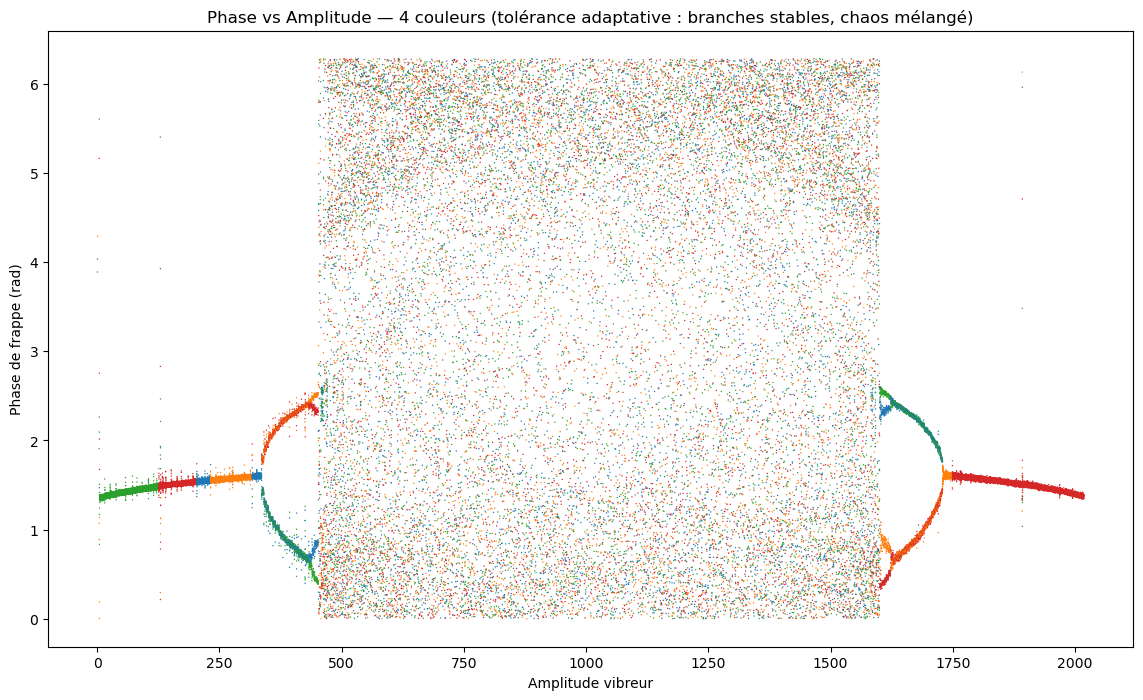

In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

file_path = "Sans scotch 30Hz.xlsx"
df = pd.read_excel(file_path)

# X = amplitude vibreur (colonne C), Y = phase (colonne E)
A = df.iloc[:, 0].to_numpy()
phi = df.iloc[:, 4].to_numpy()

PERIOD = 2*np.pi

def circ_dist(a, b, period=PERIOD):
    a = np.mod(a, period)
    b = np.mod(b, period)
    d = np.abs(a - b)
    return np.minimum(d, period - d)

# ---- 1) On travaille sur une phase "dépliée" pour mesurer une variabilité locale
phi_mod = np.mod(phi, 2*np.pi)
phi_unw = np.unwrap(phi_mod)

# dérivée locale (variation entre impacts)
dphi = np.abs(np.diff(phi_unw, prepend=phi_unw[0]))

# ---- 2) Mesure de "chaoticité" locale : moyenne glissante de dphi
W = 31  # fenêtre (impair). 21-51 marche bien.
kernel = np.ones(W) / W
dphi_smooth = np.convolve(dphi, kernel, mode="same")

# ---- 3) Tolérance adaptative
# - tol_max : pour zones périodiques (stabilise les branches)
# - tol_min : pour zones chaotiques (force du switch => mélange)
tol_max = 0.3
tol_min = 0.03

# On normalise dphi_smooth de façon robuste (évite que 2 gros pics ruinent tout)
q1, q9 = np.quantile(dphi_smooth, [0.10, 0.90])
x = np.clip((dphi_smooth - q1) / (q9 - q1 + 1e-12), 0, 1)

# x ~ 0 => périodique, x ~ 1 => chaotique
tol = tol_max * (1 - x) + tol_min * x

# ---- 4) Coloration "LabVIEW-like" : on switch de couleur seulement quand on dépasse la tolérance LOCALE
labels = np.zeros(len(phi_mod), dtype=int)
current = 0

for i in range(1, len(phi_mod)):
    if circ_dist(phi_mod[i], phi_mod[i-1]) > tol[i]:
        current = (current + 1) % 4
    labels[i] = current

# ---- 5) Plot avec 4 couleurs fixes
cmap4 = ListedColormap(["tab:blue", "tab:orange", "tab:green", "tab:red"])

plt.figure(figsize=(14, 8))
plt.scatter(A, phi_mod, c=labels, cmap=cmap4, s=1, linewidths=0)
plt.xlabel("Amplitude vibreur")
plt.ylabel("Phase de frappe (rad)")
plt.title("Phase vs Amplitude — 4 couleurs (tolérance adaptative : branches stables, chaos mélangé)")
plt.show()